In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

(array([2., 0., 0., 0., 1., 1., 0., 0., 0., 1.]),
 array([0.95316933, 0.98831299, 1.02345665, 1.05860032, 1.09374398,
        1.12888765, 1.16403131, 1.19917498, 1.23431864, 1.26946231,
        1.30460597]),
 <BarContainer object of 10 artists>)

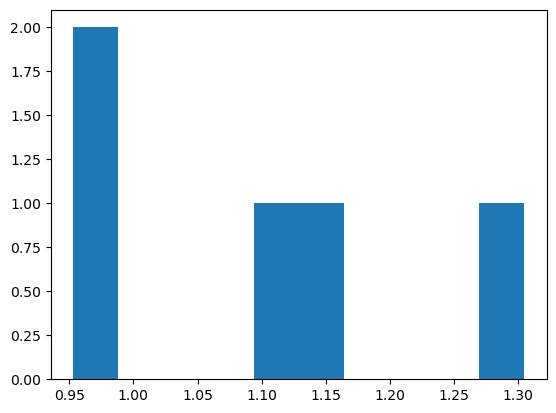

In [4]:
N= 5
np.random.seed(42)
pos_star =np.random.normal(loc=1, scale=0.2, size=N) #misurazioni centrate in ogni punto
#pos_star = norm.rvs(loc=1, scale=0.2, size=N) #modo equivalente di scrivere quello fatto sopra
plt.hist(pos_star) #istogramma per testare distribuzione

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_16412\1833008503.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


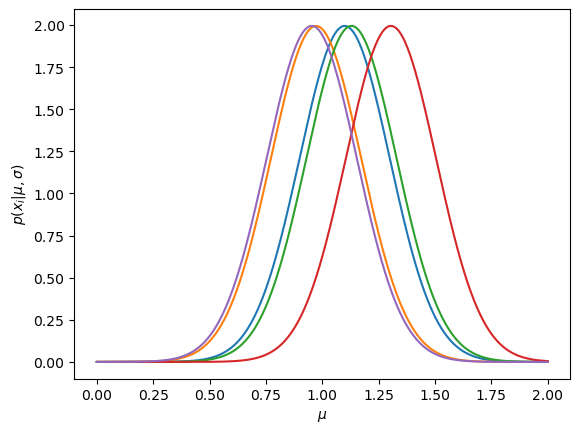

In [5]:
x = np.linspace(0, 2, 1000) #asse x
for i in range(len(pos_star)): 
    pdf_gauss = norm.pdf(x, loc=pos_star[i], scale=0.2)
    plt.plot(x, pdf_gauss)
    plt.xlabel('$\mu$') 
    plt.ylabel(r'$p(x_i|\mu,\sigma)$')

In [9]:
x = np.linspace(0, 2, 1000)
pdf_gauss_tot = []
for i in pos_star: 
    pdf_gauss = norm.pdf(x, loc=i, scale=0.2)
    pdf_gauss_tot.append(pdf_gauss)

#print(pdf_gauss_tot)
like = np.prod(pdf_gauss_tot, axis=0)
#print(like)
ln_like = np.log(like) #log in base e 
#print(like)
#print(len(like))

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_16412\2192796137.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


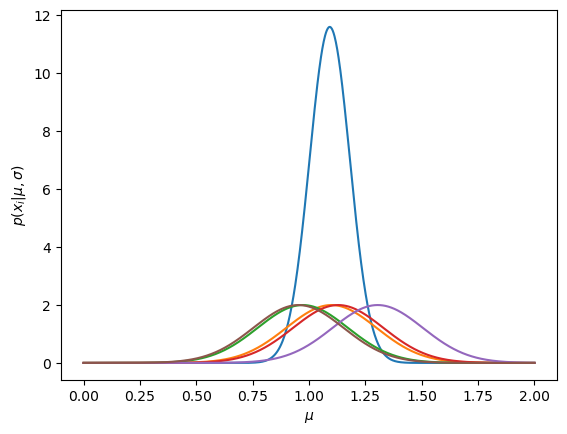

In [11]:
plt.plot(x, like)
for i in range(len(pos_star)): 
    pdf_gauss = norm.pdf(x, loc=pos_star[i], scale=0.2)
    plt.plot(x, pdf_gauss)
    plt.xlabel('$\mu$') 
    plt.ylabel(r'$p(x_i|\mu,\sigma)$')

In [15]:
#print(np.argsort(like))
arg_max_like = np.argmax(like)
print(arg_max_like)

545


maximum of the likelihood:
11.580002432834881
maximum x:
1.0910910910910911
mean position of the star:
1.0918005948650173


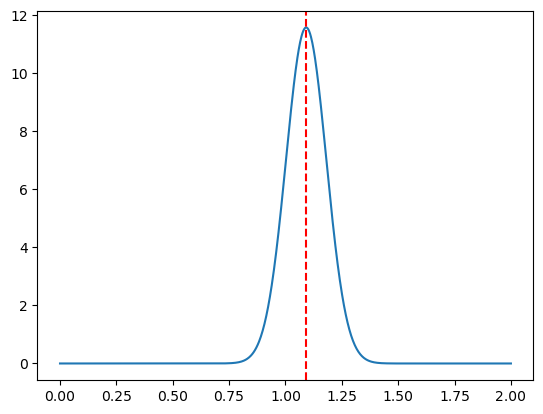

In [17]:
max_like = like[arg_max_like]
max_x = x[arg_max_like]

print("maximum of the likelihood:")
print(max_like)

print("maximum x:")
print(max_x)

pos_star_mean = np.mean(pos_star)
print("mean position of the star:")
print(pos_star_mean)

plt.plot(x, like)
plt.axvline(max_x, color="red", linestyle="--")

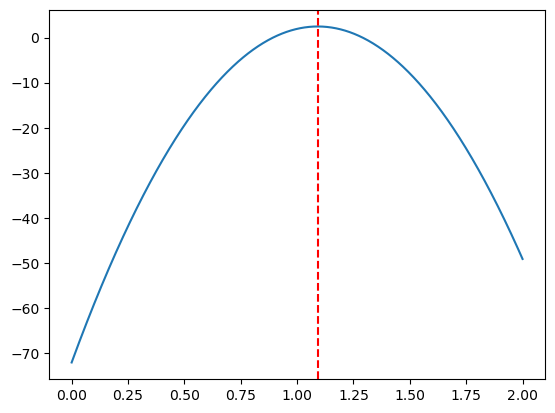

In [83]:
plt.plot(x, ln_like)
plt.axvline(max_x, color="red", linestyle="--")

In [85]:
#print(np.argsort(ln_like))

In [1018]:
max_ln_like = ln_like[np.argmax(ln_like)]
print(max_ln_like)

206.87280497964568


In [23]:
delta_mu = (x[1]-x[0])
d2_ln_like = np.diff(ln_like, n=2)
fisher = -d2_ln_like/delta_mu**2

In [25]:
#print(fisher)

In [27]:
sigma_mu = 1/np.sqrt(fisher)
#print(sigma_mu) 

In [107]:
sigma_mle = 0.2/N**0.5
print(sigma_mle)

0.08944271909999159


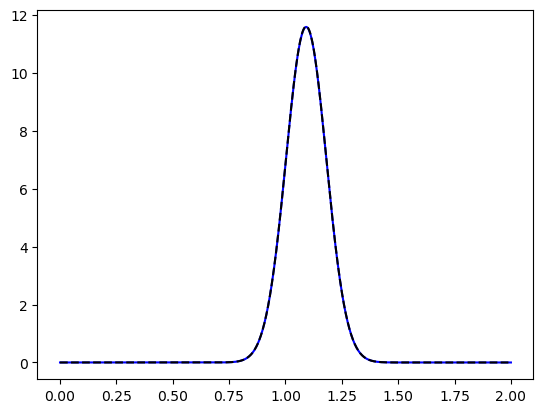

In [121]:
C = 2.6 
pdf_mle = norm.pdf(x, loc=pos_star_mean, scale=sigma_mle)
plt.plot(x, like, color="blue")
plt.plot(x, pdf_mle*C, color="black", linestyle="--")

## generalization with sigma distributed in a normal way

(array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0.,
        0., 0., 1.]),
 array([0.10433599, 0.10972409, 0.1151122 , 0.12050031, 0.12588841,
        0.13127652, 0.13666463, 0.14205273, 0.14744084, 0.15282894,
        0.15821705, 0.16360516, 0.16899326, 0.17438137, 0.17976948,
        0.18515758, 0.19054569, 0.19593379, 0.2013219 , 0.20671001,
        0.21209811]),
 <BarContainer object of 20 artists>)

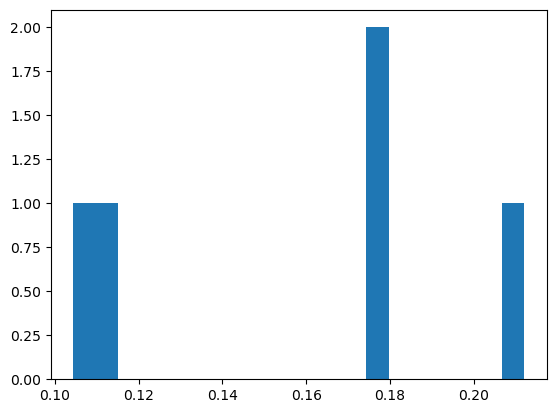

In [39]:
N= 5
pos_star =norm.rvs(loc=1, scale=0.2, size=N) #misurazioni centrate in ogni punto
sigma_star = norm.rvs(loc=0.2, scale=0.05, size=N)
plt.hist(sigma_star, bins=20) 

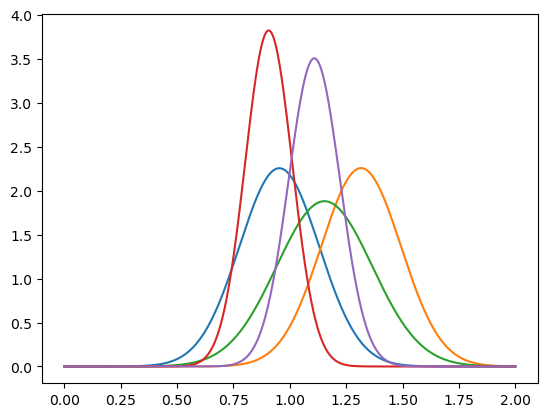

In [40]:
x = np.linspace(0, 2, 1000) #asse x
for i in range(len(pos_star)): 
    pdf_gauss = norm.pdf(x, loc=pos_star[i], scale=sigma_star[i])
    plt.plot(x, pdf_gauss)

In [43]:
pdf_gauss_tot = []
for i in range(len(pos_star)): 
    pdf_gauss = norm.pdf(x, loc=pos_star[i], scale=sigma_star[i])
    pdf_gauss_tot.append(pdf_gauss)

#print(pdf_gauss_tot)
like_gen = np.prod(pdf_gauss_tot, axis=0)
ln_like_gen = np.log(like_gen) #log in base e 
#print(like_gen)
#print(len(like_gen))

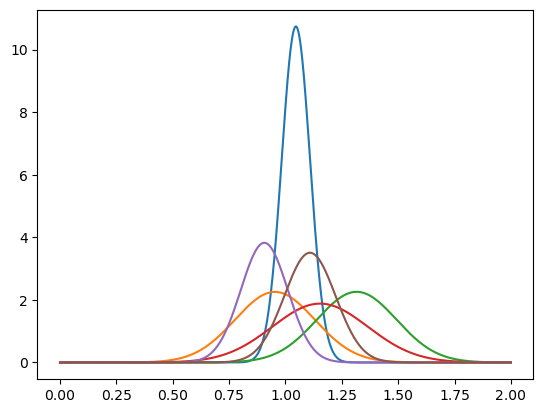

In [45]:
plt.plot(x, like_gen)
for i in range(len(pos_star)): 
    pdf_gauss = norm.pdf(x, loc=pos_star[i], scale=sigma_star[i])
    plt.plot(x, pdf_gauss)

In [47]:
arg_max_like_gen = np.argmax(like_gen)
print(arg_max_like_gen)

523


maximum of the likelihood:
10.736097235854807
maximum x:
1.047047047047047
mean position of star:
1.0874238498144853


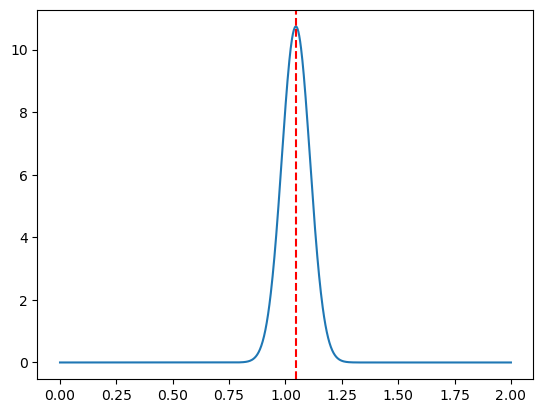

In [49]:
max_like_gen = like_gen[arg_max_like_gen]
max_x_gen = x[arg_max_like_gen]

print("maximum of the likelihood:")
print(max_like_gen)

print("maximum x:")
print(max_x_gen)

pos_star_mean = np.mean(pos_star)
print("mean position of star:")
print(pos_star_mean)

plt.plot(x, like_gen)
plt.axvline(max_x_gen, color="red", linestyle="--")

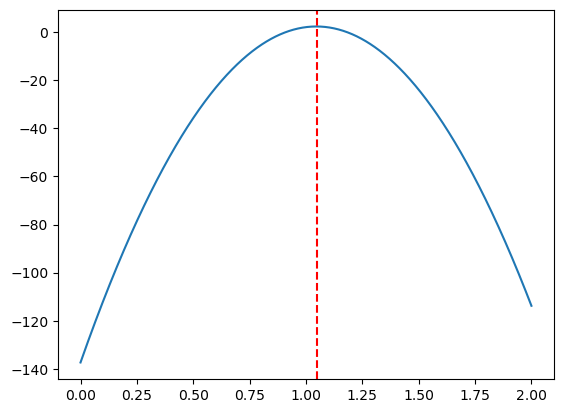

In [138]:
plt.plot(x, ln_like_gen)
plt.axvline(max_x_gen, color="red", linestyle="--")

In [51]:
max_ln_like_gen = ln_like_gen[np.argmax(ln_like_gen)]
print(max_ln_like_gen)

2.3736116371792586


In [158]:
#qui devo considerare che la deviazione standard non è fissa 
delta_mu = (x[1]-x[0])
#delta_sigma = come mai non considero variazione su sigma
d2_ln_like_gen = np.diff(ln_like_gen, n=2)
fisher = -d2_ln_like_gen/(delta_mu**2)

In [53]:
#fisher

In [55]:
sigma_mu = 1/np.sqrt(fisher)
#print(sigma_mu) 